In [ ]:
import duckdb
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

con = duckdb.connect('../olist.db')

df_retention = con.execute("""
    SELECT customer_state, AVG(date_diff('day', order_purchase_timestamp, order_delivered_customer_date)) as avg_delivery
    FROM orders JOIN customers USING (customer_id)
    GROUP BY 1
""").df()



Matplotlib is building the font cache; this may take a moment.


/var/folders/qf/45krzj0j3375x24y93x4mdbc0000gn/T/ipykernel_21695/2802580847.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bar = sns.barplot(


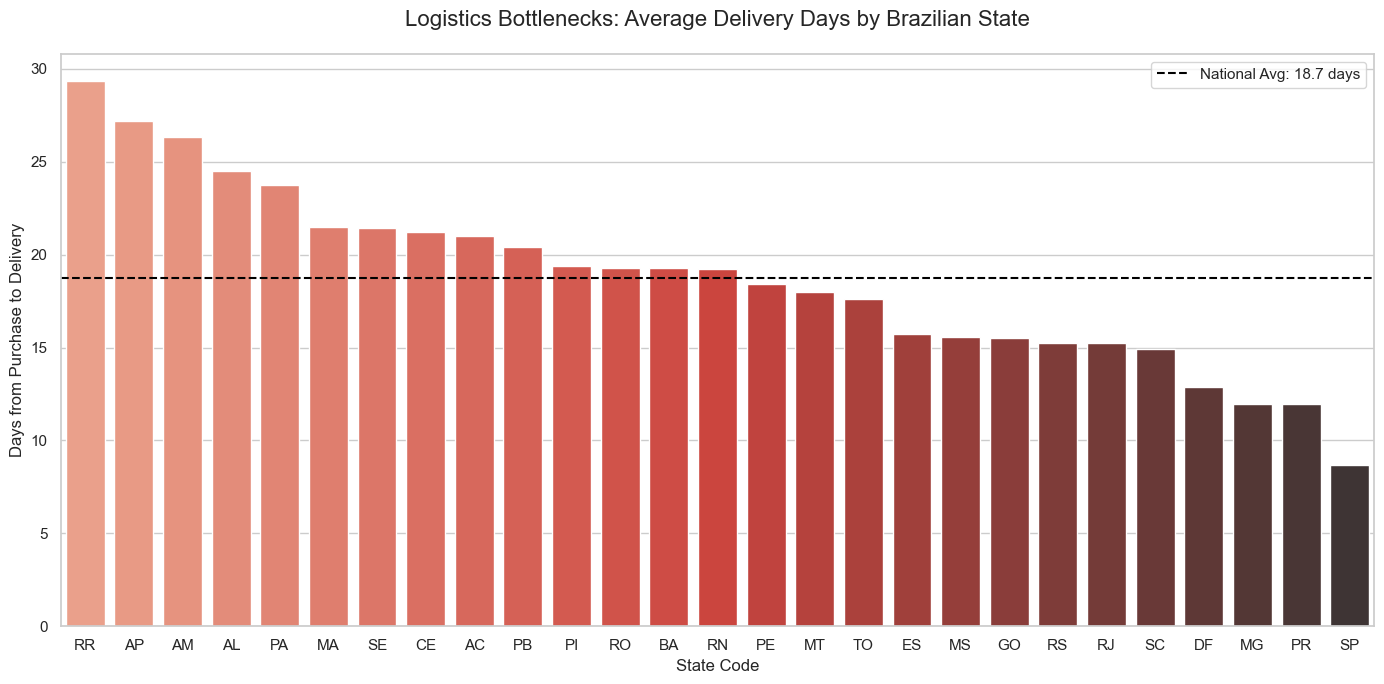

In [2]:
# 1. Prepare the data
df_plot = df_retention.sort_values('avg_delivery', ascending=False)

# 2. Set the style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 7))

# 3. Create the bar chart
bar = sns.barplot(
    data=df_plot, 
    x='customer_state', 
    y='avg_delivery', 
    palette='Reds_d' # Using Reds to highlight 'danger' areas
)

# 4. Add context (The "Senior Analyst" touches)
plt.axhline(df_plot['avg_delivery'].mean(), color='black', linestyle='--', label=f"National Avg: {df_plot['avg_delivery'].mean():.1f} days")
plt.title('Logistics Bottlenecks: Average Delivery Days by Brazilian State', fontsize=16, pad=20)
plt.xlabel('State Code', fontsize=12)
plt.ylabel('Days from Purchase to Delivery', fontsize=12)
plt.xticks(rotation=0)
plt.legend()

# 5. Show it
plt.tight_layout()
plt.show()

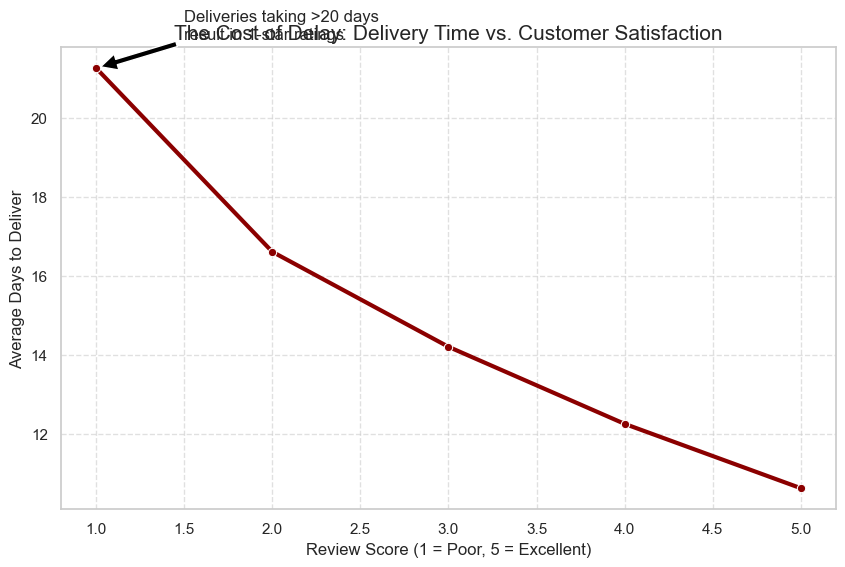

In [3]:
# 1. Pull data for Review Score vs. Delivery Time
df_reviews = con.execute("""
    SELECT 
        review_score,
        AVG(date_diff('day', order_purchase_timestamp::TIMESTAMP, order_delivered_customer_date::TIMESTAMP)) AS avg_delivery_days
    FROM orders
    JOIN order_reviews USING (order_id)
    WHERE order_status = 'delivered' 
      AND order_delivered_customer_date IS NOT NULL
    GROUP BY 1
    ORDER BY 1
""").df()

# 2. Plotting the correlation
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_reviews, x='review_score', y='avg_delivery_days', marker='o', color='darkred', linewidth=3)

# 3. Aesthetics
plt.title('The Cost of Delay: Delivery Time vs. Customer Satisfaction', fontsize=15)
plt.xlabel('Review Score (1 = Poor, 5 = Excellent)', fontsize=12)
plt.ylabel('Average Days to Deliver', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

# Add a text annotation to highlight the insight
plt.annotate('Deliveries taking >20 days\nresult in 1-star ratings', 
             xy=(1, df_reviews.iloc[0]['avg_delivery_days']), 
             xytext=(1.5, 22),
             arrowprops=dict(facecolor='black', shrink=0.05))

plt.show()